In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from pathlib import Path

In [2]:
DATA_DIR = Path("./train_historical_data")


def time_to_minutes(value):
    if pd.isna(value):
        return np.nan
    return value.hour * 60 + value.minute


def add_rollover_minutes(group, time_column):
    minutes = group[time_column].apply(time_to_minutes)
    rollover_days = 0
    previous_minute = np.nan
    absolute_minutes = []

    for minute in minutes:
        if pd.isna(minute):
            absolute_minutes.append(np.nan)
            continue

        if not pd.isna(previous_minute) and minute < previous_minute - (12 * 60):
            rollover_days += 1

        absolute_minutes.append(minute + (rollover_days * 24 * 60))
        previous_minute = minute

    return pd.Series(absolute_minutes, index=group.index)


def preprocess_journey_file(path: Path) -> pd.DataFrame:
    dataset = pd.read_excel(path)
    dataset.columns = dataset.columns.str.strip()
    dataset = dataset.drop(columns=["late_canc_reason"], errors="ignore")
    dataset["date_of_service"] = pd.to_datetime(dataset["date_of_service"])
    dataset["location"] = dataset["location"].astype(str).str.strip().str.upper()
    dataset["_row_order"] = np.arange(len(dataset))
    dataset["rid"] = path.stem + "_" + dataset["rid"].astype(str)

    dataset = dataset.sort_values(["rid", "_row_order"]).copy()
    dataset["stop_number"] = dataset.groupby("rid").cumcount()
    for col, src in [
        ("planned_arrival_minutes", "planned_arrival_time"),
        ("actual_arrival_minutes", "actual_arrival_time"),
        ("planned_departure_minutes", "planned_departure_time"),
        ("actual_departure_minutes", "actual_departure_time"),
    ]:
        dataset[col] = dataset.groupby("rid", group_keys=False).apply(
            lambda group: add_rollover_minutes(group, src)
        )

    # Origin terminus often has departure only; other stops use arrival when available.
    dataset["current_planned_minutes"] = dataset["planned_arrival_minutes"].combine_first(
        dataset["planned_departure_minutes"]
    )
    dataset["current_actual_minutes"] = dataset["actual_arrival_minutes"].combine_first(
        dataset["actual_departure_minutes"]
    )
    return dataset


def build_modelling_rows(dataset: pd.DataFrame, destination: str) -> pd.DataFrame:
    destination = destination.upper()
    dest_rows = dataset[dataset["location"] == destination][
        ["rid", "stop_number", "planned_arrival_minutes", "actual_arrival_minutes"]
    ].rename(
        columns={
            "stop_number": "dest_stop_number",
            "planned_arrival_minutes": "planned_dest_minutes",
            "actual_arrival_minutes": "actual_dest_minutes",
        }
    )

    rows = dataset.merge(dest_rows, on="rid", how="inner")
    rows = rows[rows["stop_number"] <= rows["dest_stop_number"]].copy()

    rows["current_delay"] = rows["current_actual_minutes"] - rows["current_planned_minutes"]
    rows["planned_time_now"] = rows["current_planned_minutes"] % (24 * 60)
    rows["remaining_minutes"] = rows["planned_dest_minutes"] - rows["current_planned_minutes"]
    rows["stops_remaining"] = rows["dest_stop_number"] - rows["stop_number"]
    rows["day_of_week"] = rows["date_of_service"].dt.dayofweek
    rows["y_final_delay"] = rows["actual_dest_minutes"] - rows["planned_dest_minutes"]
    return rows


journey_chunks = []
for path in sorted(DATA_DIR.glob("*.xlsx")):
    stem = path.stem.upper()
    if stem.endswith("WEY2WAT"):
        destination = "WAT"
        direction_wey2wat = 1
    elif stem.endswith("WAT2WEY"):
        destination = "WEY"
        direction_wey2wat = 0
    else:
        continue

    dataset = preprocess_journey_file(path)
    chunk = build_modelling_rows(dataset, destination)
    chunk["direction_wey2wat"] = direction_wey2wat
    journey_chunks.append(chunk)
    print(f"{path.name}: {len(chunk):,} rows -> destination {destination}")

model_data = pd.concat(journey_chunks, ignore_index=True)
all_station_codes = sorted(model_data["location"].dropna().unique())

model_data = model_data.dropna(
    subset=[
        "current_delay",
        "planned_time_now",
        "remaining_minutes",
        "stops_remaining",
        "day_of_week",
        "y_final_delay",
    ]
)

station_columns = pd.get_dummies(model_data["location"], prefix="station", dtype=int)
station_columns = station_columns.reindex(
    columns=[f"station_{station}" for station in all_station_codes],
    fill_value=0,
)
model_data_with_ids = pd.concat(
    [
        model_data[["rid"]],
        model_data[
            [
                "current_delay",
                "planned_time_now",
                "remaining_minutes",
                "stops_remaining",
                "day_of_week",
                "direction_wey2wat",
            ]
        ],
        station_columns,
        model_data[["y_final_delay"]],
    ],
    axis=1,
)

int_columns = model_data_with_ids.columns.drop("rid")
model_data_with_ids[int_columns] = model_data_with_ids[int_columns].astype(int)
model_data = model_data_with_ids.drop(columns=["rid"])
output_path = DATA_DIR / "modelling_data.csv"
model_data.to_csv(output_path, index=False)

print(
    f"\nSaved {len(model_data):,} rows from {len(journey_chunks)} files to {output_path}"
)
print(
    "Direction split:",
    model_data["direction_wey2wat"].value_counts().rename({1: "WEY2WAT", 0: "WAT2WEY"}),
)
model_data.head()

2022_WAT2WEY.xlsx: 127,858 rows -> destination WEY
2022_WEY2WAT.xlsx: 28,591 rows -> destination WAT
2023_WAT2WEY.xlsx: 135,169 rows -> destination WEY
2023_WEY2WAT.xlsx: 26,165 rows -> destination WAT
2024_WAT2WEY.xlsx: 155,138 rows -> destination WEY
2024_WEY2WAT.xlsx: 144,205 rows -> destination WAT
2025_WAT2WEY.xlsx: 159,020 rows -> destination WEY
2025_WEY2WAT.xlsx: 147,898 rows -> destination WAT

Saved 877,297 rows from 8 files to train_historical_data/modelling_data.csv
Direction split: direction_wey2wat
WAT2WEY    545987
WEY2WAT    331310
Name: count, dtype: int64


,current_delay,planned_time_now,remaining_minutes,stops_remaining,day_of_week,direction_wey2wat,station_ANF,station_BCU,station_BEU,station_BFN,...,station_WEY,station_WIM,station_WIN,station_WNF,station_WOK,station_WOO,station_WPL,station_WRM,station_WYB,y_final_delay
0,-1,330,196,28,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1,1,337,189,27,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
2,-1,343,183,26,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,2
3,-1,359,167,25,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,2
4,0,380,146,24,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [3]:
# Keep terminus rows in the CSV, but exclude them when training/scoring.
# At the journey destination (WAT on WEY2WAT, WEY on WAT2WEY), current_delay is already the final delay.
training_data = model_data_with_ids[
    (model_data_with_ids["station_WAT"] == 0) & (model_data_with_ids["station_WEY"] == 0)
].copy()

X = training_data.drop(columns=["rid", "y_final_delay"])
y = training_data["y_final_delay"]
groups = training_data["rid"]
# print("groups", groups)

# Split by train journey, not by row, so stops from the same train do not appear in both sets.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_index, test_index = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_index]
X_test = X.iloc[test_index]
y_train = y.iloc[train_index]
y_test = y.iloc[test_index]

print("Full training data:", X.shape, y.shape)
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Unique train journeys:", groups.iloc[train_index].nunique())
print("Unique test journeys:", groups.iloc[test_index].nunique())

Full training data: (781564, 68) (781564,)
Train: (625179, 68) (625179,)
Test: (156385, 68) (156385,)
Unique train journeys: 38764
Unique test journeys: 9692


## Train Linear Regression Model

model              Ridge Linear Regression
MAE_minutes                       4.238736
RMSE_minutes                      7.919169
R2                                0.855579
within_5_min                      0.748972
within_10_min                     0.926943
within_15_min                     0.966045
large_delay_MAE                  22.381002


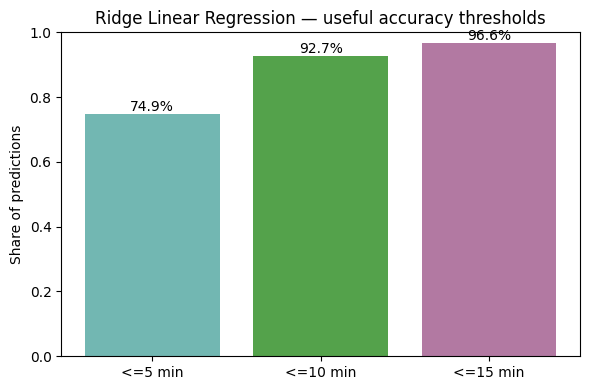

In [4]:
def regression_metrics(model_name, y_true, y_pred):
    errors = y_pred - y_true
    absolute_errors = np.abs(errors)
    y_true_array = np.asarray(y_true)
    large_delay_mask = y_true_array >= 30

    return {
        "model": model_name,
        "MAE_minutes": mean_absolute_error(y_true, y_pred),
        "RMSE_minutes": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "within_5_min": np.mean(absolute_errors <= 5),
        "within_10_min": np.mean(absolute_errors <= 10),
        "within_15_min": np.mean(absolute_errors <= 15),
        "large_delay_MAE": mean_absolute_error(y_true_array[large_delay_mask], y_pred[large_delay_mask]),
    }


def plot_regression_diagnostics(model_name, y_true, y_pred):
    absolute_errors = np.abs(y_pred - y_true)

    threshold_labels = ["<=5 min", "<=10 min", "<=15 min"]
    threshold_values = [
        np.mean(absolute_errors <= 5),
        np.mean(absolute_errors <= 10),
        np.mean(absolute_errors <= 15),
    ]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(threshold_labels, threshold_values, color=["#72B7B2", "#54A24B", "#B279A2"])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of predictions")
    ax.set_title(f"{model_name} — useful accuracy thresholds")
    for index, value in enumerate(threshold_values):
        ax.text(index, value, f"{value:.1%}", ha="center", va="bottom")

    fig.tight_layout()
    plt.show()


model_scores = []

# Ridge is still a linear regression model, but regularisation makes it more stable
# with many one-hot station columns than plain LinearRegression.
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_metrics = regression_metrics("Ridge Linear Regression", y_test, linear_pred)
model_scores.append(linear_metrics)
print(pd.Series(linear_metrics).to_string())
plot_regression_diagnostics("Ridge Linear Regression", y_test, linear_pred)

## Train Histogram Gradient Boosting Model

model              HistGradientBoosting
MAE_minutes                    4.138271
RMSE_minutes                  19.112298
R2                             0.158802
within_5_min                   0.781757
within_10_min                  0.938754
within_15_min                  0.970048
large_delay_MAE               21.574211


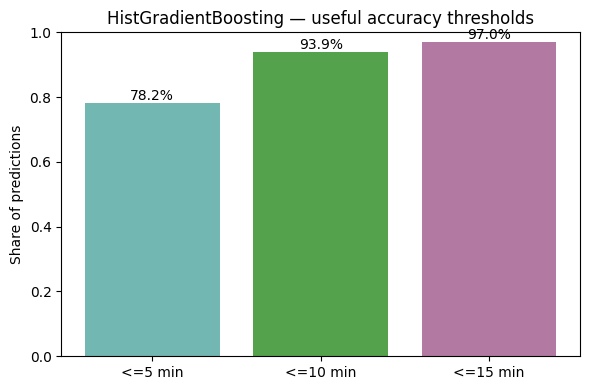

In [5]:
# Gradient boosting handles non-linear relationships between station, current delay,
# remaining time, and final delay better than a straight-line model.
# I tested a weighted version for rare severe delays, but it reduced overall MAE/RMSE,
# so this unweighted version is the better default comparison model.
hist_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    random_state=42,
)
hist_model.fit(X_train, y_train)
hist_pred = hist_model.predict(X_test)

hist_metrics = regression_metrics("HistGradientBoosting", y_test, hist_pred)
model_scores.append(hist_metrics)
print(pd.Series(hist_metrics).to_string())
plot_regression_diagnostics("HistGradientBoosting", y_test, hist_pred)

## Train XGBoost Model

model                XGBoost
MAE_minutes         4.146054
RMSE_minutes       19.230595
R2                  0.148356
within_5_min        0.779339
within_10_min       0.938651
within_15_min       0.970035
large_delay_MAE    21.682756


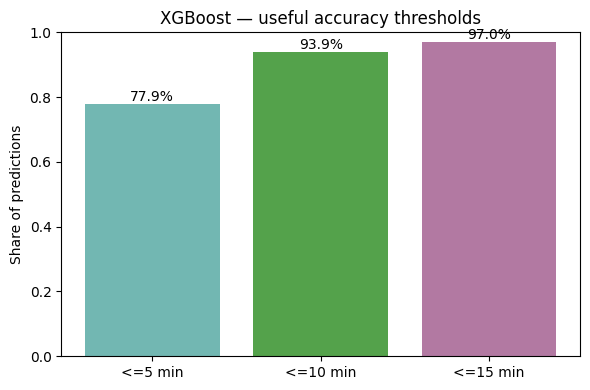

In [6]:
# XGBoost is another gradient-boosted tree model; compare with HistGradientBoosting on the same split.
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_metrics = regression_metrics("XGBoost", y_test, xgb_pred)
model_scores.append(xgb_metrics)
print(pd.Series(xgb_metrics).to_string())
plot_regression_diagnostics("XGBoost", y_test, xgb_pred)

## Train KNN Model

model                    KNN
MAE_minutes         4.456112
RMSE_minutes       19.632389
R2                  0.112397
within_5_min        0.760636
within_10_min       0.910011
within_15_min       0.957036
large_delay_MAE    21.957221


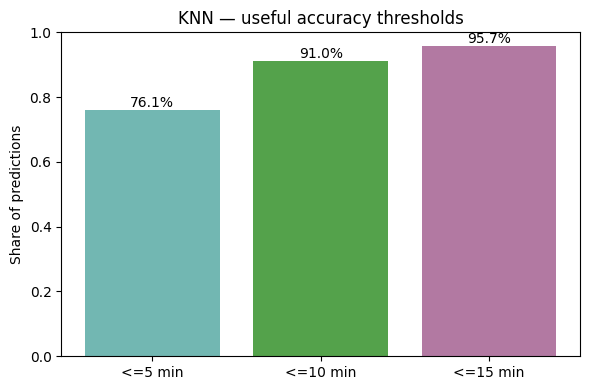

In [7]:
# KNN is distance-based, so scaling matters. Full KNN over 100k+ rows can be slow,
# so this uses a reproducible sample as a practical baseline model.
# knn_train_size = min(10_000, len(X_train))
# knn_train_index = X_train.sample(n=knn_train_size, random_state=42).index
#
# X_train_knn = X_train.loc[knn_train_index]
# y_train_knn = y_train.loc[knn_train_index]

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=7, weights="distance")),
])

knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

knn_metrics = regression_metrics("KNN", y_test, knn_pred)
model_scores.append(knn_metrics)
print(pd.Series(knn_metrics).to_string())
plot_regression_diagnostics("KNN", y_test, knn_pred)

## Train Decision Tree Model

model              Decision Tree
MAE_minutes             4.348364
RMSE_minutes           19.246942
R2                      0.146908
within_5_min            0.763801
within_10_min           0.932212
within_15_min           0.966512
large_delay_MAE         22.34621


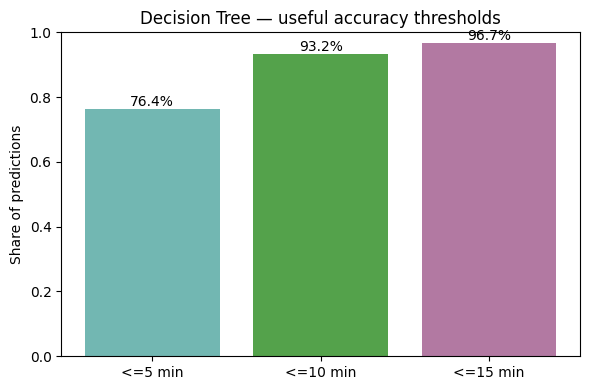

In [8]:
# Decision trees can capture non-linear station/delay interactions, but depth and
# leaf-size limits help stop the tree from memorising individual train journeys.
decision_tree_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=50,
    random_state=42,
)

decision_tree_model.fit(X_train, y_train)
decision_tree_pred = decision_tree_model.predict(X_test)

decision_tree_metrics = regression_metrics("Decision Tree", y_test, decision_tree_pred)
model_scores.append(decision_tree_metrics)
print(pd.Series(decision_tree_metrics).to_string())
plot_regression_diagnostics("Decision Tree", y_test, decision_tree_pred)

Best model by metric:
lowest_MAE                 HistGradientBoosting
lowest_RMSE             Ridge Linear Regression
highest_R2              Ridge Linear Regression
best_within_5_min          HistGradientBoosting
best_within_10_min         HistGradientBoosting
best_within_15_min         HistGradientBoosting
lowest_large_delay_MAE     HistGradientBoosting

Overall ranking by MAE (primary):
                  model  MAE_minutes  RMSE_minutes       R2  within_10_min
   HistGradientBoosting     4.138271     19.112298 0.158802       0.938754
                XGBoost     4.146054     19.230595 0.148356       0.938651
Ridge Linear Regression     4.238736      7.919169 0.855579       0.926943
          Decision Tree     4.348364     19.246942 0.146908       0.932212
                    KNN     4.456112     19.632389 0.112397       0.910011


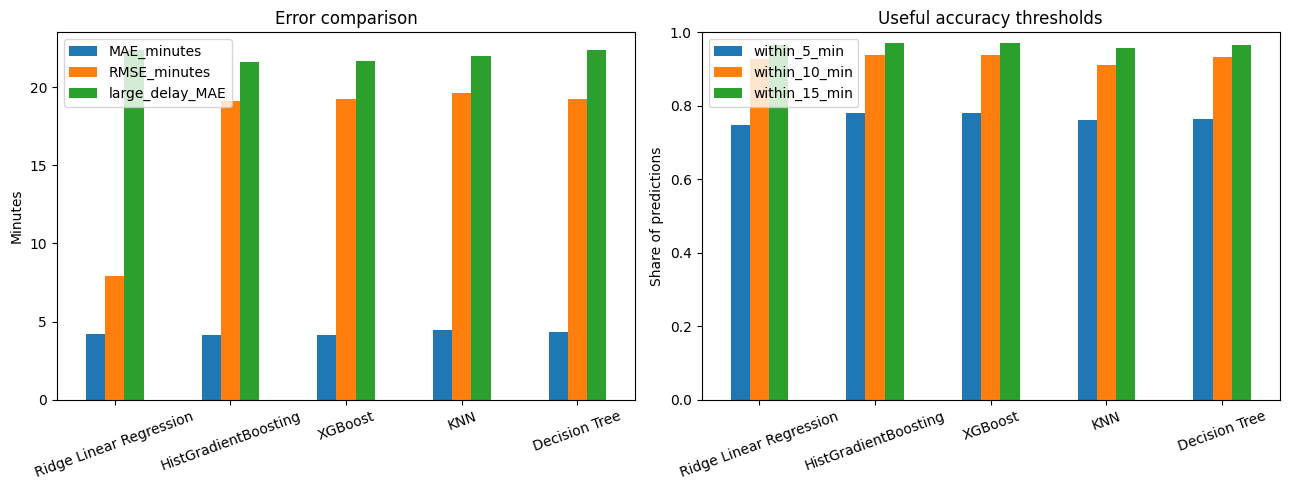

,model,MAE_minutes,RMSE_minutes,R2,within_5_min,within_10_min,within_15_min,large_delay_MAE
0,Ridge Linear Regression,4.238736,7.919169,0.855579,0.748972,0.926943,0.966045,22.381002
1,HistGradientBoosting,4.138271,19.112298,0.158802,0.781757,0.938754,0.970048,21.574211
2,XGBoost,4.146054,19.230595,0.148356,0.779339,0.938651,0.970035,21.682756
3,KNN,4.456112,19.632389,0.112397,0.760636,0.910011,0.957036,21.957221
4,Decision Tree,4.348364,19.246942,0.146908,0.763801,0.932212,0.966512,22.346210


In [9]:
scores = pd.DataFrame(model_scores)

rankings = pd.DataFrame({
    "lowest_MAE": [scores.loc[scores["MAE_minutes"].idxmin(), "model"]],
    "lowest_RMSE": [scores.loc[scores["RMSE_minutes"].idxmin(), "model"]],
    "highest_R2": [scores.loc[scores["R2"].idxmax(), "model"]],
    "best_within_5_min": [scores.loc[scores["within_5_min"].idxmax(), "model"]],
    "best_within_10_min": [scores.loc[scores["within_10_min"].idxmax(), "model"]],
    "best_within_15_min": [scores.loc[scores["within_15_min"].idxmax(), "model"]],
    "lowest_large_delay_MAE": [scores.loc[scores["large_delay_MAE"].idxmin(), "model"]],
})
print("Best model by metric:")
print(rankings.T.to_string(header=False))

print("\nOverall ranking by MAE (primary):")
print(
    scores.sort_values("MAE_minutes")[["model", "MAE_minutes", "RMSE_minutes", "R2", "within_10_min"]]
    .to_string(index=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scores.plot(x="model", y=["MAE_minutes", "RMSE_minutes", "large_delay_MAE"], kind="bar", ax=axes[0])
axes[0].set_ylabel("Minutes")
axes[0].set_xlabel("")
axes[0].set_title("Error comparison")
axes[0].tick_params(axis="x", rotation=20)

scores.plot(x="model", y=["within_5_min", "within_10_min", "within_15_min"], kind="bar", ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Share of predictions")
axes[1].set_xlabel("")
axes[1].set_title("Useful accuracy thresholds")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()

scores

Metric	Meaning
MAE_minutes	Average absolute prediction error in minutes

RMSE_minutes	Error in minutes, but punishes big mistakes more

R2	How much variation in final delay the model explains

within_5_min	% of predictions within 5 minutes of the real delay

within_10_min	% of predictions within 10 minutes

within_15_min	% of predictions within 15 minutes

large_delay_MAE	MAE only for large delays, e.g. actual delay >= 30 min

## Model rankings (best → worst)

Per-metric leaderboards and an average-rank summary. Lower average rank = better overall (MAE is the primary deployment metric).


MAE (min) — primary (best → worst)
 rank                   model  MAE_minutes
    1    HistGradientBoosting       4.1383
    2                 XGBoost       4.1461
    3 Ridge Linear Regression       4.2387
    4           Decision Tree       4.3484
    5                     KNN       4.4561

RMSE (min) (best → worst)
 rank                   model  RMSE_minutes
    1 Ridge Linear Regression        7.9192
    2    HistGradientBoosting       19.1123
    3                 XGBoost       19.2306
    4           Decision Tree       19.2469
    5                     KNN       19.6324

Large-delay MAE (≥30 min actual) (best → worst)
 rank                   model  large_delay_MAE
    1    HistGradientBoosting          21.5742
    2                 XGBoost          21.6828
    3                     KNN          21.9572
    4           Decision Tree          22.3462
    5 Ridge Linear Regression          22.3810

R² (best → worst)
 rank                   model     R2
    1 Ridge Linear Regressio

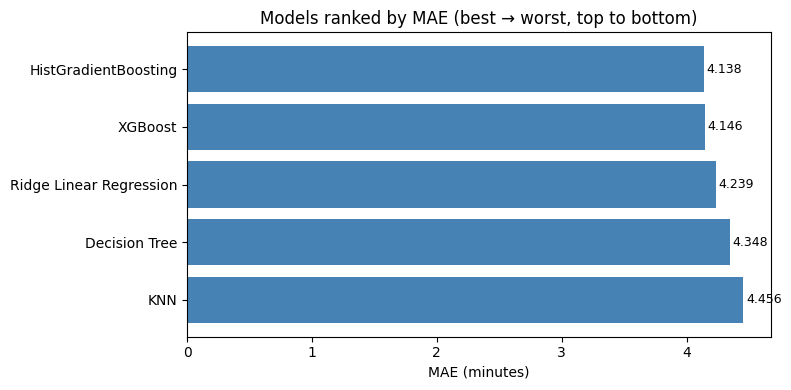

,model,rank_MAE_minutes,rank_RMSE_minutes,rank_large_delay_MAE,rank_R2,rank_within_5_min,rank_within_10_min,rank_within_15_min,avg_rank
1,HistGradientBoosting,1,2,1,2,1,1,1,1.285714
2,XGBoost,2,3,2,3,2,2,2,2.285714
0,Ridge Linear Regression,3,1,5,1,5,4,4,3.285714
4,Decision Tree,4,4,4,4,3,3,3,3.571429
3,KNN,5,5,3,5,4,5,5,4.571429


In [10]:
# Uses `scores` from the comparison cell above.
lower_is_better = ["MAE_minutes", "RMSE_minutes", "large_delay_MAE"]
higher_is_better = ["R2", "within_5_min", "within_10_min", "within_15_min"]

metric_labels = {
    "MAE_minutes": "MAE (min) — primary",
    "RMSE_minutes": "RMSE (min)",
    "R2": "R²",
    "within_5_min": "Within 5 min (%)",
    "within_10_min": "Within 10 min (%)",
    "within_15_min": "Within 15 min (%)",
    "large_delay_MAE": "Large-delay MAE (≥30 min actual)",
}

rank_tables = {}
for col in lower_is_better + higher_is_better:
    ascending = col in lower_is_better
    ordered = scores.sort_values(col, ascending=ascending).reset_index(drop=True)
    ordered.insert(0, "rank", range(1, len(ordered) + 1))
    rank_tables[col] = ordered

    label = metric_labels[col]
    print(f"\n{'=' * 60}")
    print(f"{label} (best → worst)")
    print("=" * 60)
    display_cols = ["rank", "model", col]
    if col.startswith("within_"):
        display = ordered[display_cols].copy()
        display[col] = (display[col] * 100).round(2)
        print(display.to_string(index=False, formatters={col: "{:.2f}".format}))
    else:
        print(ordered[display_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Rank matrix: 1 = best for that metric
rank_matrix = pd.DataFrame({"model": scores["model"]})
for col in lower_is_better + higher_is_better:
    ascending = col in lower_is_better
    rank_matrix[f"rank_{col}"] = scores[col].rank(method="min", ascending=ascending).astype(int)

rank_matrix["avg_rank"] = rank_matrix.filter(like="rank_").mean(axis=1)
rank_matrix = rank_matrix.sort_values("avg_rank")

print(f"\n{'=' * 60}")
print("Overall summary (average rank across all metrics; 1.0 = best everywhere)")
print("=" * 60)
summary_cols = ["model", "avg_rank"] + [c for c in rank_matrix.columns if c.startswith("rank_")]
print(rank_matrix[summary_cols].to_string(index=False, float_format=lambda x: f"{x:.2f}"))

best_overall = rank_matrix.iloc[0]["model"]
best_mae = rank_tables["MAE_minutes"].iloc[0]["model"]
print(f"\nRecommended for deployment (lowest MAE): {best_mae}")
print(f"Best average rank across metrics: {best_overall}")

# Visual: MAE leaderboard (best at top)
mae_order = rank_tables["MAE_minutes"].iloc[::-1]  # worst at bottom for horizontal bar
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(mae_order["model"], mae_order["MAE_minutes"], color="steelblue")
ax.set_xlabel("MAE (minutes)")
ax.set_title("Models ranked by MAE (best → worst, top to bottom)")
for bar, val in zip(bars, mae_order["MAE_minutes"]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9)
fig.tight_layout()
plt.show()

rank_matrix